# Calvin Knowles

 # Intro to Machine Learning - Final Project 

## Introduction

This project focuses on building predictive models to estimate house sale prices using various machine learning algorithms. Utilizing the Ames Housing dataset from Kaggle, I preprocessed the data, handled missing values, encoded categorical features for easier model ingestion, and tested regression models to find the best performing. The models used in this project are Linear Regression, Random Forest Regression, and XGBoost Regression.

The objective of this project is to identify the best performing model when predicting house sale price dependent on various characteristics of previously sold houses. When evaluating performance, I utilized Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R^2 value. This project also includes various visualizations to amplify our analysis by providing easy to interpret outputs. 

## Imports

In [29]:
pip install --upgrade pip

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 145.1 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 23.3.2
    Uninstalling pip-23.3.2:
      Successfully uninstalled pip-23.3.2
  You can safely remove it manually.
  You can safely remove it manually.
Note: you may need to restart the kernel to use updated packages.


In [1]:
# Install xgboost library
!pip install xgboost

In [2]:
# Check for seaborn upgrades incase the current notebook version is outdated
!pip install seaborn --upgrade

In [3]:
# Data analysis and visualization tools
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style='whitegrid')

# Machine Learning models and performance metric functions
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import xgboost as xgb
from xgboost import XGBRegressor

## Data Loading and Preprocessing

First we will load the test and training dataset grabbed from Kaggle into Pandas dataframes. Once loaded we will check the size of the dataframe and print the first 5 rows of the training set to get an idea of where and what needs to be cleaned or encoded.

In [33]:
df = pd.read_csv('train.csv')
test_data = pd.read_csv('test.csv')
print(df.shape)
df.head()

(1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


Now that we can see a small sample of the data we can begin the cleaning and encoding process. First, I will check and clean the training dataset of null values.

In [34]:
missing = df.isnull().sum()  # Count missing values for each feature/column
missing[missing > 0].sort_values(ascending=False).head(10)  # Display the top ten features with null values > 0

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
FireplaceQu      690
LotFrontage      259
GarageYrBlt       81
GarageType        81
GarageFinish      81
GarageQual        81
dtype: int64

Here we can see there are 10 features with atleast 1 missing value as determined by our threshold of greater than 0. Let's determine a threshold and continue forward by removing features that exceed this threshold. If there is more than 10% of the data missing, we will remove the feature from our model.

In [35]:
threshold = 0.1  # Set the threshold to 10%
missing_frac = df.isnull().mean()  # Calculate the percentage of null data for each feature

# Now let's check which features exceed this threshold
missing_frac[missing_frac > threshold].sort_values(ascending=False).head(10)

PoolQC         0.995205
MiscFeature    0.963014
Alley          0.937671
Fence          0.807534
FireplaceQu    0.472603
LotFrontage    0.177397
dtype: float64

These 6 features exceed the 10 percent threshold. Because these features having a significant amount of null values, we will remove them from our analysis.

In [36]:
# Gather the 6 column names to drop from the training dataset
cols_to_drop = missing_frac[missing_frac > threshold].index.tolist()

print(f"Drop the following columns: {cols_to_drop}")

# Drop the columns from the training dataset
df = df.drop(columns = cols_to_drop)

Drop the following columns: ['LotFrontage', 'Alley', 'FireplaceQu', 'PoolQC', 'Fence', 'MiscFeature']


Now I will go through the same process in the test dataset to maintain consistency.

In [37]:
missing_test = test_data.isnull().sum()  # Count missing values for each feature
missing_test[missing_test > 0].sort_values(ascending=False).head(10) # Display the top ten features with missing values > 0

PoolQC          1456
MiscFeature     1408
Alley           1352
Fence           1169
FireplaceQu      730
LotFrontage      227
GarageYrBlt       78
GarageCond        78
GarageQual        78
GarageFinish      78
dtype: int64

In [38]:
threshold = 0.1  # Set the threshold to 10%
missing_frac = test_data.isnull().mean()  # Calculate the percentage of null data for each feature

# Now let's check which features exceed this threshold
missing_frac[missing_frac > threshold].sort_values(ascending=False).head(10)

# Gather the columns to drop from previous analysis
cols_to_drop = missing_frac[missing_frac > threshold].index.tolist()
print(f"Drop the following columns: {cols_to_drop}")

Drop the following columns: ['LotFrontage', 'Alley', 'FireplaceQu', 'PoolQC', 'Fence', 'MiscFeature']


## Histogram Showing Count of Houses by Sales Price

This visualization will provide us a clear view of our data distribution.

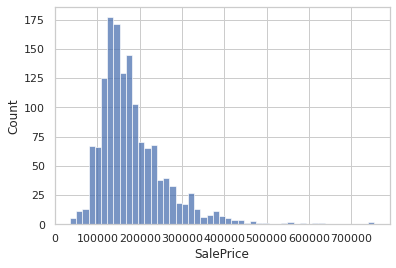

In [39]:
df.describe()
df.corr()
sns.histplot(df['SalePrice'])

Based on this result, I am hypothesizing that our model will be the most accurate when predicting houses between the sales prices of 100 to 200 thousand dollars.

## Splitting the Data and Encoding Categorical Variables
Now that we have cleaned and formed stronger understanding of our data, we can split our data into 4 separate subsets necessary for machine learning model ingestion. We will split the training data set into the following: X is the training set minus the target feature SalePrice, and y is the target feature SalePrice alone. 

Now that we have them separated, we will then break X and y into separate parts as well. 1) X_train will be used to train our machine learning models by analyzing the various features or characteristics of each home and 2) y_train is used as the known SalePrice for each respective datapoint contained in X_train. We do this so the machine learning model can find patterns in our data that may influence the sale price!

We also split the data into X_valid and y_valid. These subsets will be used as a test or validation of our trained machine learning model. Once we train the model with X_train and y_train, we will pass X_valid into the model to see how accurate it is in predicting the respective SalePrice's in y_valid.


In [40]:
# Drop the ID and target feature from the training set
X = df.drop(columns = ['Id', 'SalePrice'])

# Set the target feature
y = df['SalePrice']

# Split the data into subsets for training and validation
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)

Now that we have successfully split the data, we will encode any categorical features. Thismeans we will utilize existing algorithms that will transform the categorical features into numerical. The reasoning behind this is that machine learning models prefer numerical data. Therefore, to set ourselves up for the most accurate outputs, we will need to transform any existing categorical data.

In [41]:
# Get the categorical features
categorical_columns = X.select_dtypes(include=['object', 'category']).columns
print(categorical_columns)

# Encode the categorical features contain within X_train and X_valid. 
# Note that we do not execute this on y_train and y_valid because these subsets only contain SalePrice, a numerical value.
label_encoder = LabelEncoder()

for col in categorical_columns:
    # Combine, convert to string, and fit
    combined_data = pd.concat([X_train[col], X_valid[col]], axis=0).astype(str)
    label_encoder.fit(combined_data)

    # Transform both train and valid
    X_train[col] = label_encoder.transform(X_train[col].astype(str))
    X_valid[col] = label_encoder.transform(X_valid[col].astype(str))

Index(['MSZoning', 'Street', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
       'Functional', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
       'PavedDrive', 'SaleType', 'SaleCondition'],
      dtype='object')


In [42]:
# Check for missing values
print(X_train.isnull().sum().sort_values(ascending=False).head())
print(y_train.isnull().sum())

X_train = X_train.dropna()
y_train = y_train[X_train.index]  # Align y with new X index
X_valid = X_valid.dropna()
y_valid = y_valid[X_valid.index]


GarageYrBlt      64
MasVnrArea        6
SaleCondition     0
ExterCond         0
RoofMatl          0
dtype: int64
0


## Linear Regression
Now that we have completed preprocessing and encoding, we are ready to build our models. The first model we will test is linear regression. Linear regression is a foundational machine learning algorithm that models the relationship between one or more independent variables (features) and a dependent variable (target). In our scenario the target variable is SalePrice and the independent variables are the columns that remain in X_train.

In [59]:
lr_model = LinearRegression()

lr_model.fit(X_train, y_train)
y_pred = lr_model.predict(X_valid)

lr_mse = mean_squared_error(y_valid, y_pred)
lr_r2 = r2_score(y_valid, y_pred)

print(f'Mean Squared Error: {lr_mse:.2f}')
print(f'R-squared: {lr_r2:.4f}')
lr_rmse = np.sqrt(lr_mse)
print(f'Root Mean Squared Error: {lr_rmse:.2f}')

Mean Squared Error: 1142496887.79
R-squared: 0.8480
Root Mean Squared Error: 33800.84


## Linear Regression Interpretation
After running a linear regression on the data we are presented with two key outputs. The R-squared value is ~0.85 which is a statistically strong score that explains roughly 85% of the variance in sales price is captured through patterns in the dataset. The other metric is root mean squared error (rmse) with value of approximately 34 thousand USD. This means that our linear regression model's predictions are off by roughly plus or minus 34k. When comparing this to the average cost of a house, it is considered a low value. The lower the rmse is the more confidence we have in our model's predictions.

## Most Influential Features for Linear Regression Model
To gather an even better understanding of our model we will create a horizontal bar chart of the datasets features and their influence on predictions

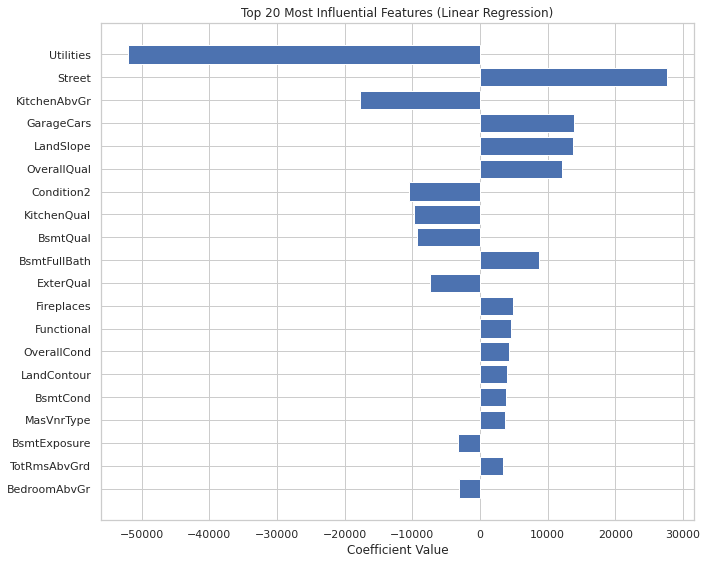

In [45]:
# Get coefficients from the model
coefficients = lr_model.coef_
features = X_train.columns

# Create a DataFrame to store coefficients
coef_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': coefficients,
    'Abs_Coefficient': np.abs(coefficients)
}).sort_values(by='Abs_Coefficient', ascending=False)

# Plot top 20 features by absolute coefficient magnitude
plt.figure(figsize=(10, 8))
plt.barh(coef_df['Feature'][:20][::-1], coef_df['Coefficient'][:20][::-1])
plt.xlabel('Coefficient Value')
plt.title('Top 20 Most Influential Features (Linear Regression)')
plt.tight_layout()
plt.show()

Here we see that utilities is the most influential feature in this model. Utilities is the largest bar and on the negative side which means homes with this feature are expected to sell for roughly 50 thousand dollars less than the average. This leads me to believe there is a lack of transparency in our data after we encoded categorical features. I think there is more nuance such as different types of utilities that may be more expensive or cheaper than others. I tested the linear regression model without the Utilities column and there was no significant change to the r-squared or rmse value, therefore, I will keep utilities for the other models as well. 

## Random Forest Regression
The linear regression model gave us a decent prediction, but I want to find out if other models may be better. The next model we will train is a random forest regression. This is an ensemble model meaning it builds multiple decision trees and combines their predictions to improve accuracy.

In [53]:
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)
y_rf_pred = rf_model.predict(X_valid)

rf_mse = mean_squared_error(y_valid, y_rf_pred)
rf_r2 = r2_score(y_valid, y_rf_pred)

print(f'Random Forest MSE: {rf_mse:.2f}')
print(f'Random Forest R²: {rf_r2:.4f}')

rf_rmse = np.sqrt(rf_mse)
print(f'Root Mean Squared Error: {rf_rmse:.2f}')

Random Forest MSE: 862608947.87
Random Forest R²: 0.8852
Root Mean Squared Error: 29370.21


Looks like we were correct to test another model! The random forest model produced an r-squared value of 0.88 and an rmse of roughly 30k USD. These are not large improvements but we are moving in the right directly. These two metrics tell us that the random forest model is more accurate at predicting house sales prices than linear regression. 

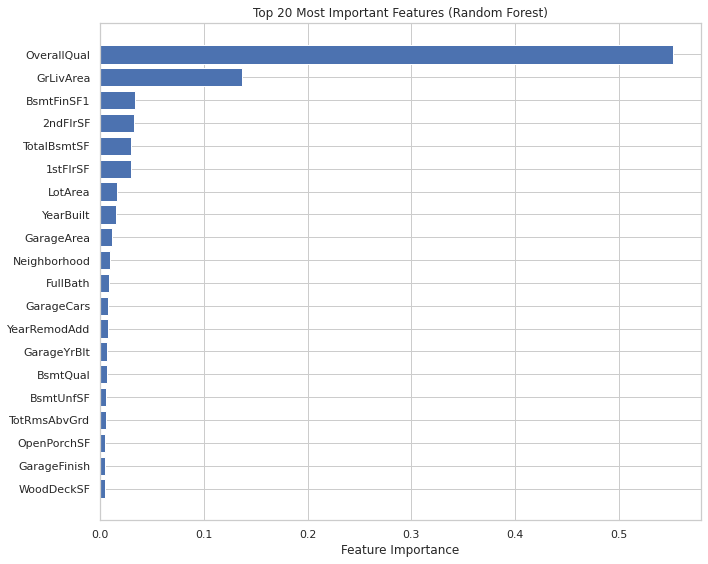

In [54]:
importances = rf_model.feature_importances_
features = X_train.columns
importance_df = pd.DataFrame({'Feature': features, 'Importance': importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 8))
plt.barh(importance_df['Feature'][:20][::-1], importance_df['Importance'][:20][::-1])
plt.xlabel('Feature Importance')
plt.title('Top 20 Most Important Features (Random Forest)')
plt.tight_layout()
plt.show()

In this model the feature with the greatest importance was Overall Quality of the house. I find that this makes more sense in influence than utilities. We are moving in the right direction. Let's try one more strong machine learning algorithm before wrapping up.

## XGBoost
XGBoost is widely considered one of the premire machine learning algorithms when it comes to accuracy and efficiency. This algorithm is based on gradient boosting which is another type of ensemble method. This model builds decision trees sequentially where each new tree focuses on correcting errors made by previous iterations.

In [55]:
# Initialize the XGBoost model
xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

# Fit the model with early stopping
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_valid, y_valid)],
    early_stopping_rounds=10,
    verbose=False
)

# Predict
y_pred = xgb_model.predict(X_valid)

XGBoost MSE: 684688675.95
XGBoost R²: 0.9089


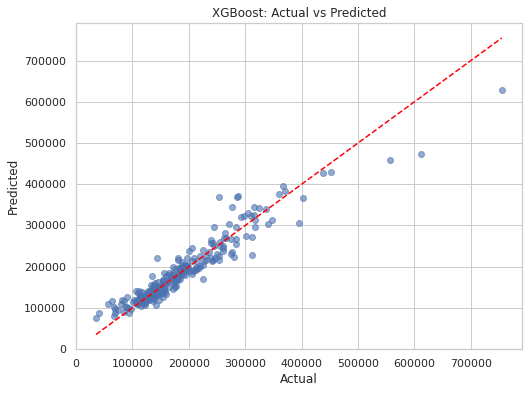

In [56]:
# Evaluate
mse = mean_squared_error(y_valid, y_pred)
r2 = r2_score(y_valid, y_pred)

print(f"XGBoost MSE: {mse:.2f}")
print(f"XGBoost R²: {r2:.4f}")

# Plot actual vs predicted
plt.figure(figsize=(8, 6))
plt.scatter(y_valid, y_pred, alpha=0.6)
plt.plot([y_valid.min(), y_valid.max()], [y_valid.min(), y_valid.max()], color='red', linestyle='--')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("XGBoost: Actual vs Predicted")
plt.grid(True)
plt.show()

As expected, xgboost output the greatest r-squared value of approximately 0.91 which means it delivered the best performance, despite not having the lowest RMSE.

## Conclusion

All three models performed well relative to one another. Linear regression was not too far behind random forest and xgboost which was expected for this problem. Random forest performed the best in regards to RMSE, meaning it made the most accurate dollar-level predictions. XGBoost performed the best in terms of r-squared which means it was the best at predicting the target variable, sales price.

Overall, it was a close battle between these models but my final recommendation is XGBoost. It is evidently the best at predicting the target.

In [62]:
# Summarize results
print(f"{'Model':<20}{'RMSE':>15}{'R²':>10}")
print(f"{'-'*60}")
print(f"{'Linear Regression':<20}{lr_rmse:15,.2f}{lr_r2:10.4f}")
print(f"{'Random Forest':<20}{rf_rmse:15,.2f}{rf_r2:10.4f}")
print(f"{'XGBoost':<20}{rmse:15,.2f}{r2:10.4f}")

Model                          RMSE        R²
------------------------------------------------------------
Linear Regression         33,800.84    0.8480
Random Forest             29,370.21    0.8852
XGBoost                   33,800.84    0.9089
